The initial data cleaning and inspection on the California Hospital Inpatient Mortality dataset.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import joblib


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, 
    confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, 
    roc_curve, auc, log_loss, matthews_corrcoef, cohen_kappa_score, r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [17]:
# Load the dataset
file_path = "California Hospital Inpatient Mortality Rates and Quality Ratings .csv"
df = pd.read_csv(file_path)
df.head()

,YEAR,COUNTY,HOSPITAL,OSHPDID,Procedure/Condition,Risk Adjuested Mortality Rate,# of Deaths,# of Cases,Hospital Ratings,LONGITUDE,LATITUDE
0,2016,AAAA,STATEWIDE,NaN,AAA Repair Unruptured,1.3,30,2358,NaN,NaN,NaN
1,2016,AAAA,STATEWIDE,NaN,AMI,6.1,3178,52167,NaN,NaN,NaN
2,2016,AAAA,STATEWIDE,NaN,Acute Stroke,9.1,5482,60184,NaN,NaN,NaN
3,2016,AAAA,STATEWIDE,NaN,Acute Stroke Hemorrhagic,21.1,2580,12210,NaN,NaN,NaN
4,2016,AAAA,STATEWIDE,NaN,Acute Stroke Ischemic,5,2258,45141,NaN,NaN,NaN


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57654 entries, 0 to 57653
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   YEAR                           57654 non-null  int64  
 1   COUNTY                         57654 non-null  object 
 2   HOSPITAL                       57654 non-null  object 
 3   OSHPDID                        57474 non-null  float64
 4   Procedure/Condition            57654 non-null  object 
 5   Risk Adjuested Mortality Rate  47880 non-null  object 
 6   # of Deaths                    47964 non-null  object 
 7   # of Cases                     47964 non-null  object 
 8   Hospital Ratings               36178 non-null  object 
 9   LONGITUDE                      57446 non-null  object 
 10  LATITUDE                       57446 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 4.8+ MB


In [66]:
df.describe()

,YEAR,OSHPDID
count,57654.000000,5.747400e+04
mean,2018.472266,1.062815e+08
std,1.836958,1.366034e+05
min,2016.000000,1.060107e+08
25%,2017.000000,1.061904e+08
50%,2018.000000,1.063012e+08
75%,2020.000000,1.063714e+08
max,2022.000000,1.065810e+08


In [18]:
# Initial cleaning
df = df[df['HOSPITAL'] != 'STATEWIDE']  # Drop STATEWIDE rows
df.replace({'.': np.nan, ' ': np.nan, '': np.nan}, inplace=True)  # Standardize missing values
df = df[df['Hospital Ratings'].notna()]  # Drop rows with missing target

In [19]:
# Preview cleaned dataset
head = df.head()
middle = df.iloc[len(df)//2 : len(df)//2 + 5]
tail = df.tail()

# Null counts
null_counts = df.isnull().sum()

head

,YEAR,COUNTY,HOSPITAL,OSHPDID,Procedure/Condition,Risk Adjuested Mortality Rate,# of Deaths,# of Cases,Hospital Ratings,LONGITUDE,LATITUDE
17,2016,Alameda,Alameda Hospital,106010735.0,AMI,16.1,3,17,As Expected,-122.253991,37.76266
18,2016,Alameda,Alameda Hospital,106010735.0,Acute Stroke,23.6,9,74,Worse,-122.253991,37.76266
19,2016,Alameda,Alameda Hospital,106010735.0,Acute Stroke Hemorrhagic,48.9,5,9,Worse,-122.253991,37.76266
20,2016,Alameda,Alameda Hospital,106010735.0,Acute Stroke Ischemic,15.2,4,65,As Expected,-122.253991,37.76266
24,2016,Alameda,Alameda Hospital,106010735.0,GI Hemorrhage,4.6,5,83,As Expected,-122.253991,37.76266


In [20]:
middle

,YEAR,COUNTY,HOSPITAL,OSHPDID,Procedure/Condition,Risk Adjuested Mortality Rate,# of Deaths,# of Cases,Hospital Ratings,LONGITUDE,LATITUDE
28827,2016,Santa Clara,Santa Clara Valley Medical Center,106430883.0,PCI,5.8,5,148,As Expected,-121.93202,37.31346
28828,2016,Santa Clara,Santa Clara Valley Medical Center,106430883.0,Pancreatic Cancer,.,.,.,NaN,-121.93202,37.31346
28829,2016,Santa Clara,Santa Clara Valley Medical Center,106430883.0,Pancreatic Other,0,0,3,As Expected,-121.93202,37.31346
28830,2016,Santa Clara,Santa Clara Valley Medical Center,106430883.0,Pancreatic Resection,0,0,5,As Expected,-121.93202,37.31346
28831,2016,Santa Clara,Santa Clara Valley Medical Center,106430883.0,Pneumonia,3.8,4,184,As Expected,-121.93202,37.31346


In [21]:
tail

,YEAR,COUNTY,HOSPITAL,OSHPDID,Procedure/Condition,Risk Adjuested Mortality Rate,# of Deaths,# of Cases,Hospital Ratings,LONGITUDE,LATITUDE
57649,2022,Yuba,Adventist Health and Rideout,106580996.0,Heart Failure,3.6,23,712,As Expected,-121.593602,39.138805
57650,2022,Yuba,Adventist Health and Rideout,106580996.0,Hip Fracture,4,6,167,As Expected,-121.593602,39.138805
57651,2022,Yuba,Adventist Health and Rideout,106580996.0,PCI,4.3,7,146,As Expected,-121.593602,39.138805
57652,2022,Yuba,Adventist Health and Rideout,106580996.0,Pancreatic Resection,NaN,NaN,NaN,NaN,-121.593602,39.138805
57653,2022,Yuba,Adventist Health and Rideout,106580996.0,Pneumonia,11.9,46,470,Worse,-121.593602,39.138805


In [22]:
null_counts

YEAR                                 0
COUNTY                               0
HOSPITAL                             0
OSHPDID                            180
Procedure/Condition                  0
Risk Adjuested Mortality Rate     9774
# of Deaths                       9690
# of Cases                        9690
Hospital Ratings                 21476
LONGITUDE                          208
LATITUDE                           208
dtype: int64

 Visual insights into the cleaned dataset to help inform decisions about imputation and modeling.

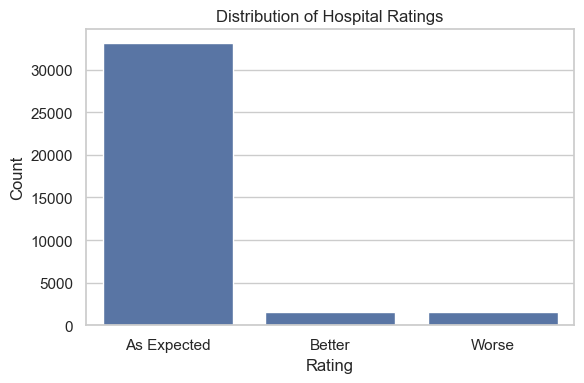

In [ ]:
# Set consistent styling for plots
sns.set(style="whitegrid")

# Bar chart: Distribution of Hospital Ratings
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Hospital Ratings', order=df['Hospital Ratings'].value_counts().index)
plt.title("Distribution of Hospital Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

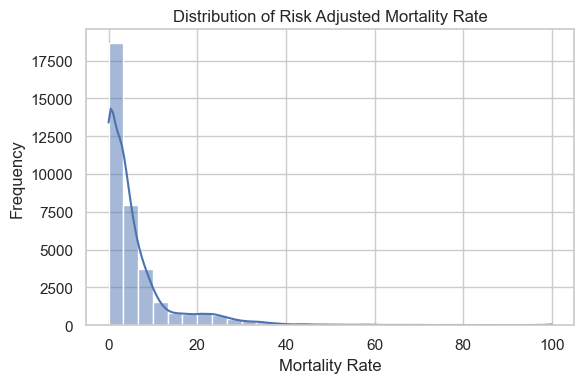

In [ ]:
# Histogram: Risk Adjusted Mortality Rate (convert to numeric first)
df['Risk Adjuested Mortality Rate'] = pd.to_numeric(df['Risk Adjuested Mortality Rate'], errors='coerce')

plt.figure(figsize=(6, 4))
sns.histplot(df['Risk Adjuested Mortality Rate'].dropna(), bins=30, kde=True)
plt.title("Distribution of Risk Adjusted Mortality Rate")
plt.xlabel("Mortality Rate")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

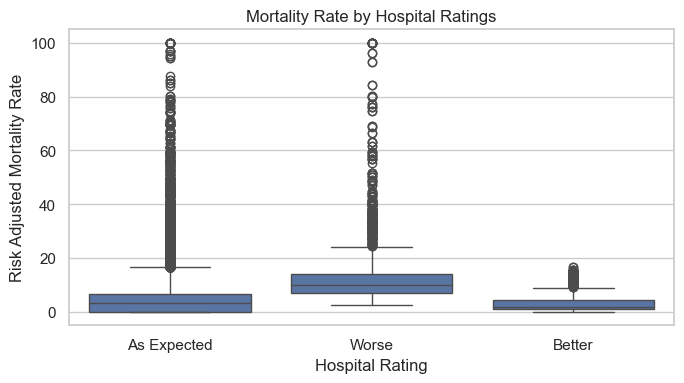

In [53]:
# Boxplot: Mortality Rate grouped by Hospital Ratings
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Hospital Ratings', y='Risk Adjuested Mortality Rate')
plt.title("Mortality Rate by Hospital Ratings")
plt.xlabel("Hospital Rating")
plt.ylabel("Risk Adjusted Mortality Rate")
plt.tight_layout()
plt.show()

In [20]:
# Drop irrelevant columns if they exist
df.drop(columns=["LONGITUDE", "LATITUDE"], errors="ignore", inplace=True)
# Drop OSHPDID (identifier column)
df.drop(columns=["OSHPDID"], inplace=True)


In [21]:
# Impute missing mortality rate with median
df["Risk Adjuested Mortality Rate"] = pd.to_numeric(df["Risk Adjuested Mortality Rate"], errors="coerce")
df['Risk Adjuested Mortality Rate'] = df.groupby('HOSPITAL')['Risk Adjuested Mortality Rate'].transform(lambda x: x.fillna(x.median()))


df["# of Deaths"] = pd.to_numeric(df["# of Deaths"], errors="coerce")
df["# of Cases"] = pd.to_numeric(df["# of Cases"], errors="coerce")

# Fill missing categorical columns with 'Unknown'
df["HOSPITAL"].fillna("Unknown", inplace=True)
df["COUNTY"].fillna("Unknown", inplace=True)

# Fill missing categorical columns with 'mode'
df["Procedure/Condition"] = df.groupby("HOSPITAL")["Procedure/Condition"].transform(lambda x: x.fillna(x.mode()[0]))

In [22]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Apply outlier removal
df = remove_outliers(df, ["Risk Adjuested Mortality Rate", "# of Deaths", "# of Cases"])


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29182 entries, 17 to 57651
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   YEAR                           29182 non-null  int64  
 1   COUNTY                         29182 non-null  object 
 2   HOSPITAL                       29182 non-null  object 
 3   Procedure/Condition            29182 non-null  object 
 4   Risk Adjuested Mortality Rate  29182 non-null  float64
 5   # of Deaths                    29182 non-null  int64  
 6   # of Cases                     29182 non-null  int64  
 7   Hospital Ratings               29182 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 2.0+ MB


In [23]:
# Feature Engineering
# Mortality per Case
df['Mortality_Per_Case'] = df['Risk Adjuested Mortality Rate'] / df['# of Cases']
df["Mortality_Per_Case"] = pd.to_numeric(df["Mortality_Per_Case"], errors="coerce")

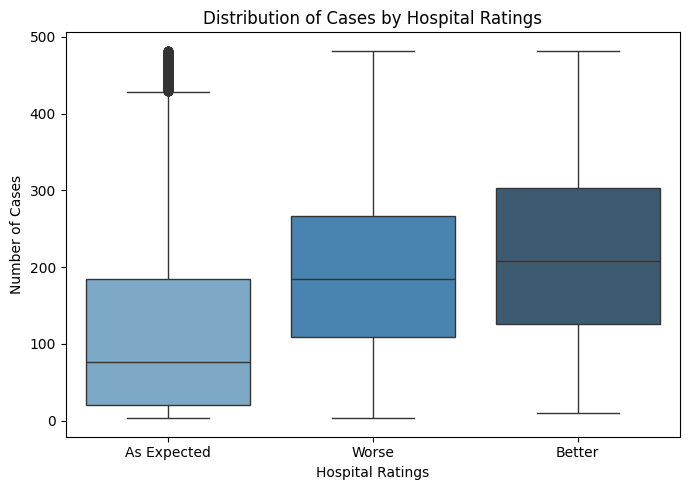

In [10]:
plt.figure(figsize=(7, 5))
sns.boxplot(x=df["Hospital Ratings"], y=df["# of Cases"], palette="Blues_d")
plt.title("Distribution of Cases by Hospital Ratings")
plt.xlabel("Hospital Ratings")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()

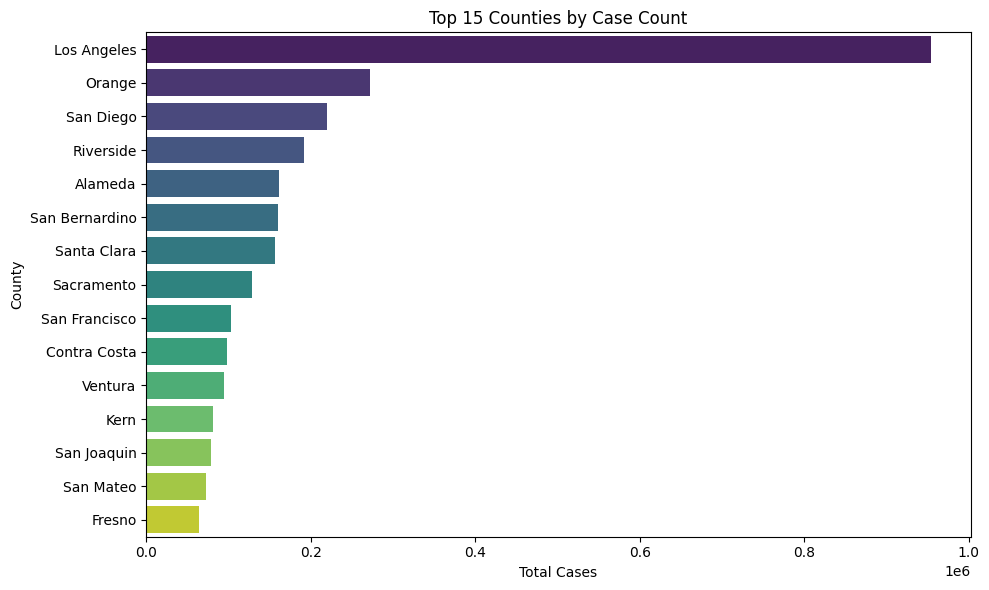

In [75]:
# Top 15 counties by total case count
top_counties = df.groupby("COUNTY")["# of Cases"].sum().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_counties.values, y=top_counties.index, palette="viridis")
plt.title("Top 15 Counties by Case Count")
plt.xlabel("Total Cases")
plt.ylabel("County")
plt.tight_layout()
plt.show()


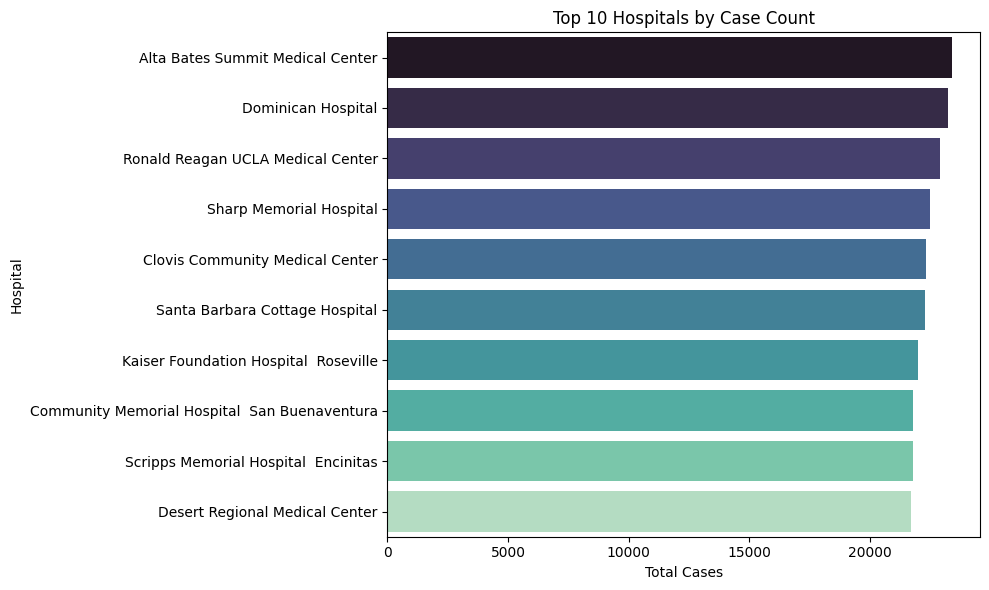

In [76]:
# Top 10 hospitals by total case count
top_hospitals = df.groupby("HOSPITAL")["# of Cases"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_hospitals.values, y=top_hospitals.index, palette="mako")
plt.title("Top 10 Hospitals by Case Count")
plt.xlabel("Total Cases")
plt.ylabel("Hospital")
plt.tight_layout()
plt.show()



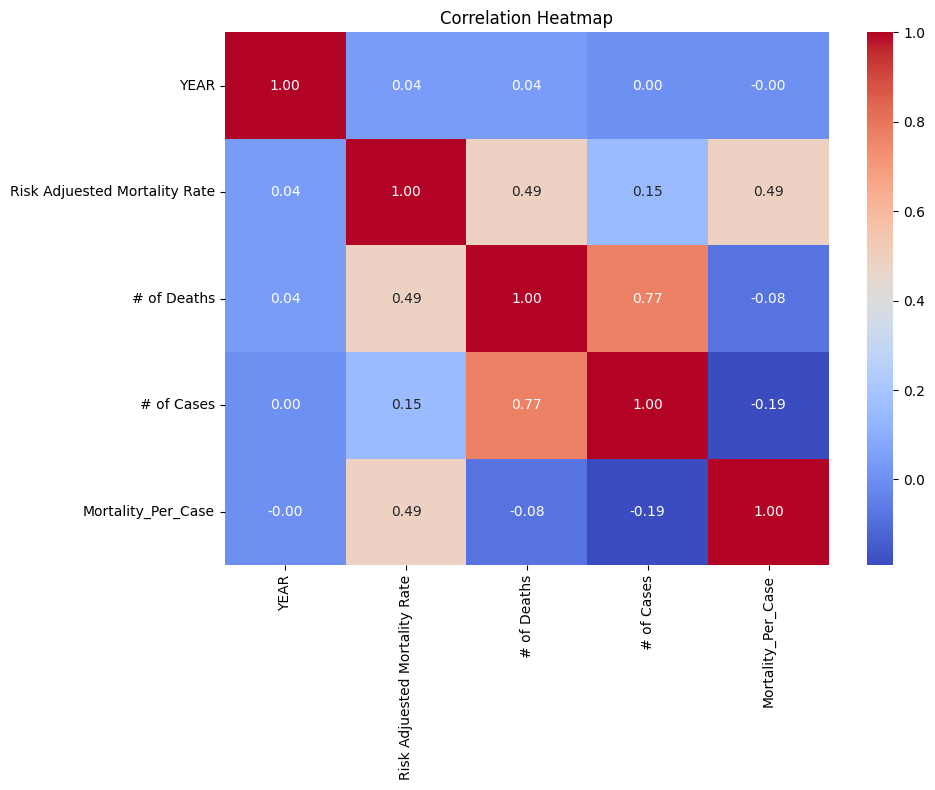

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [24]:
# Label Encoding
le_proc = LabelEncoder()
le_hosp = LabelEncoder()
le_county = LabelEncoder()
le_rating = LabelEncoder()

df["Procedure/Condition"] = le_proc.fit_transform(df["Procedure/Condition"])
df["HOSPITAL"] = le_hosp.fit_transform(df["HOSPITAL"])
df["COUNTY"] = le_county.fit_transform(df["COUNTY"])

custom_label_map = {'Worse': 0, 'As Expected': 1, 'Better': 2}
df["Hospital Ratings"] = df["Hospital Ratings"].map(custom_label_map)
label_mapping = custom_label_map
label_mapping


{'Worse': 0, 'As Expected': 1, 'Better': 2}

In [25]:

# Prepare features and target
X = df.drop(columns=["Hospital Ratings"])
y = df["Hospital Ratings"]

# Train-test split with stratification
X_train_orig, X_test, y_train_orig, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Show class distribution in original training set

original_class_counts = y_train_orig.value_counts()

original_class_counts


Hospital Ratings
1    21945
2      898
0      502
Name: count, dtype: int64

In [26]:
# Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_orig, y_train_orig)

# Show balanced class distribution after SMOTE
smote_class_counts = y_train_smote.value_counts()
smote_class_counts


Hospital Ratings
1    21945
2    21945
0    21945
Name: count, dtype: int64

In [28]:
# 4 models 

def train_random_forest(X, y):
    model = RandomForestClassifier(random_state=42)
    model.fit(X, y)
    return model

def train_xgboost(X, y):
    model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    model.fit(X, y)
    return model

def train_knn(X, y):
    model = KNeighborsClassifier()
    model.fit(X, y)
    return model

def train_svm(X, y):
    model = SVC(probability=True, random_state=42)
    model.fit(X, y)
    return model


In [29]:
# Train models on original data
rf_orig = train_random_forest(X_train_orig, y_train_orig)
xgb_orig = train_xgboost(X_train_orig, y_train_orig)
knn_orig = train_knn(X_train_orig, y_train_orig)
svm_orig = train_svm(X_train_orig, y_train_orig)

# Train models on SMOTE-balanced data
rf_smote = train_random_forest(X_train_smote, y_train_smote)
xgb_smote = train_xgboost(X_train_smote, y_train_smote)
knn_smote = train_knn(X_train_smote, y_train_smote)
svm_smote = train_svm(X_train_smote, y_train_smote)

In [30]:

# Save trained models
joblib.dump(rf_orig, 'rf_model_original.pkl')
joblib.dump(xgb_orig, 'xgb_model_original.pkl')
joblib.dump(knn_orig, 'knn_model_original.pkl')
joblib.dump(svm_orig, 'svm_model_original.pkl')

# Save models trained on SMOTE data similarly
joblib.dump(rf_smote, 'rf_model_smote.pkl')
joblib.dump(xgb_smote, 'xgb_model_smote.pkl')
joblib.dump(knn_smote, 'knn_model_smote.pkl')
joblib.dump(svm_smote, 'svm_model_smote.pkl')


['svm_model_smote.pkl']

In [31]:
# Load saved models
rf_orig = joblib.load('rf_model_original.pkl')
xgb_orig = joblib.load('xgb_model_original.pkl')
knn_orig = joblib.load('knn_model_original.pkl')
svm_orig = joblib.load('svm_model_original.pkl')

# Load models trained on SMOTE data similarly
rf_smote = joblib.load('rf_model_smote.pkl')
xgb_smote = joblib.load('xgb_model_smote.pkl')
knn_smote = joblib.load('knn_model_smote.pkl')
svm_smote = joblib.load('svm_model_smote.pkl')


In [32]:
# Visualization for Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, 
                xticklabels=["Worse", "As Expected", "Better"], 
                yticklabels=["Worse", "As Expected", "Better"])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Visualization for ROC Curve
def plot_roc_curve(y_true, y_prob, title="ROC-AUC Curve"):
    # Extract probabilities for class '1' ("As Expected")
    y_prob_class_1 = y_prob[:, 1]  # Class 1: "As Expected"

    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob_class_1, pos_label=1)  # pos_label=1 for "As Expected"
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color="b", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

# Model Evaluation
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    # For multi-class, use probabilities for all classes (not just positive class)
    y_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    print(f" {model_name} Evaluation:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
    print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
    print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))
    print("F1 Score (micro):", f1_score(y_test, y_pred, average='micro'))

    # For multi-class, if y_prob is available, compute additional metrics
    if y_prob is not None:
        print("ROC AUC (macro):", roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'))
        print("Log Loss:", log_loss(y_test, y_prob))

    print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
    print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
    print("Root Mean Squared Error (RMSE):", mean_squared_error(y_test, y_pred, squared=False))
    print("Mean Absolute Percentage Error (MAPE):", np.mean(np.abs((y_test - y_pred) / y_test)) * 100)
    
    #print("Matthews Correlation Coefficient:", matthews_corrcoef(y_test, y_pred))
    #print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))

    if y_prob is not None:
        print("R-squared:", r2_score(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plotting Confusion Matrix
    plot_confusion_matrix(y_test, y_pred)

    # Plotting ROC AUC Curve
    if y_prob is not None:
        plot_roc_curve(y_test, y_prob)


 Random Forest (Original) Evaluation:
Accuracy: 0.9873222545828336
Precision (macro): 0.9795661648444297
Recall (macro): 0.8690221331227345
F1 Score (macro): 0.9178799288072993
F1 Score (micro): 0.9873222545828336
ROC AUC (macro): 0.9965740170667955
Log Loss: 0.048055278029544436
Mean Absolute Error (MAE): 0.012677745417166352
Mean Squared Error (MSE): 0.012677745417166352
Root Mean Squared Error (RMSE): 0.11259549465749663
Mean Absolute Percentage Error (MAPE): inf
R-squared: 0.787531419857842
Confusion Matrix:
[[  95   30    0]
 [   0 5477   10]
 [   0   34  191]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.76      0.86       125
           1       0.99      1.00      0.99      5487
           2       0.95      0.85      0.90       225

    accuracy                           0.99      5837
   macro avg       0.98      0.87      0.92      5837
weighted avg       0.99      0.99      0.99      5837



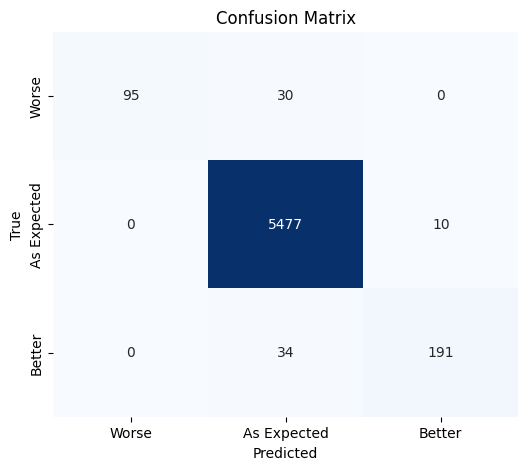

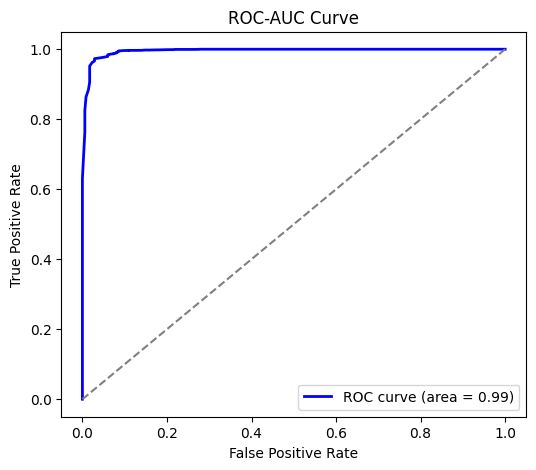

In [33]:
evaluate_model(rf_orig, X_test, y_test, "Random Forest (Original)")

📊 XGBoost (Original) Evaluation:
Accuracy: 0.990187949143173
Precision (macro): 0.9729618042564102
ROC AUC (macro): 0.9979732930121331
Confusion Matrix:
[[ 278   23    0]
 [   7 6597   15]
 [   0   26  290]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       301
           1       0.99      1.00      0.99      6619
           2       0.95      0.92      0.93       316

    accuracy                           0.99      7236
   macro avg       0.97      0.95      0.96      7236
weighted avg       0.99      0.99      0.99      7236



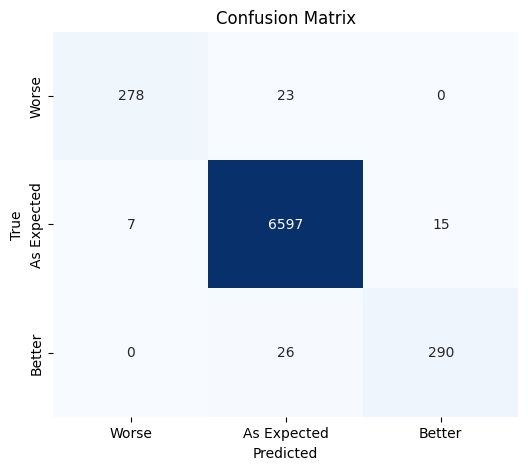

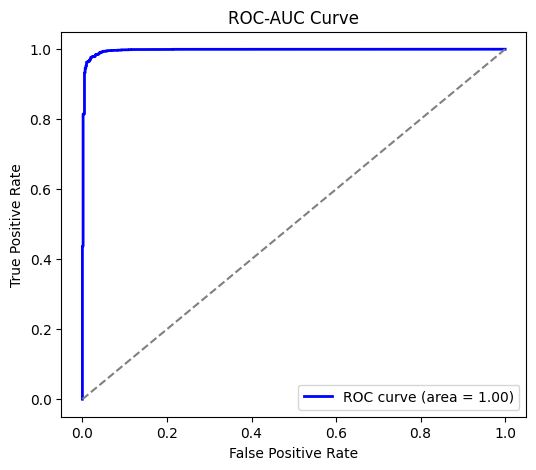

In [30]:
evaluate_model(xgb_orig, X_test, y_test, "XGBoost (Original)")

 KNN (Original) Evaluation:
Accuracy: 0.9154228855721394
Precision (macro): 0.640666137644251
Recall (macro): 0.4583353063643454
F1 Score (macro): 0.5059462796279884
F1 Score (micro): 0.9154228855721394
ROC AUC (macro): 0.8449895048028524
Log Loss: 0.8351830303551091
Mean Absolute Error (MAE): 0.0855444997236042
Mean Squared Error (MSE): 0.08747927031509121
Root Mean Squared Error (RMSE): 0.2957689475166235
Mean Absolute Percentage Error (MAPE): inf
Matthews Correlation Coefficient: 0.29383189708754426
Cohen's Kappa: 0.2624693474989357
R-squared: -0.025983634483300655
Confusion Matrix:
[[  61  240    0]
 [  56 6503   60]
 [   7  249   60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.20      0.29       301
           1       0.93      0.98      0.96      6619
           2       0.50      0.19      0.28       316

    accuracy                           0.92      7236
   macro avg       0.64      0.46      0.51      7236
we

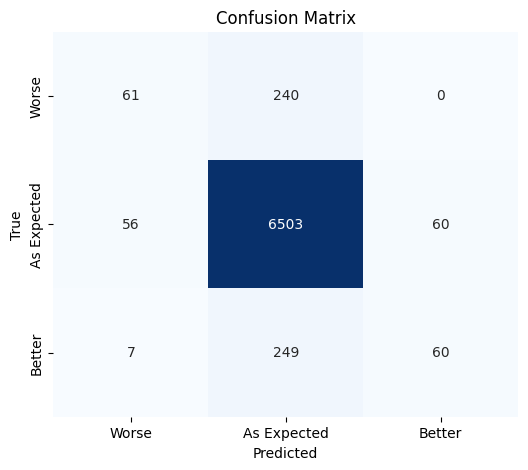

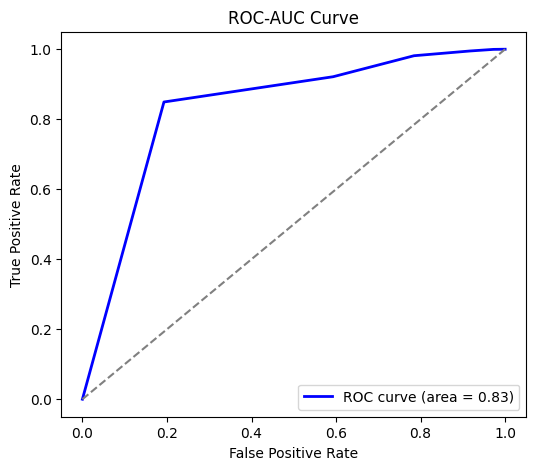

In [62]:

evaluate_model(knn_orig, X_test, y_test, "KNN (Original)")

📊 SVM (Original) Evaluation:
Accuracy: 0.9147318960751797
Precision (macro): 0.3049106320250599
ROC AUC (macro): 0.3172198211398876
Confusion Matrix:
[[   0  301    0]
 [   0 6619    0]
 [   0  316    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       301
           1       0.91      1.00      0.96      6619
           2       0.00      0.00      0.00       316

    accuracy                           0.91      7236
   macro avg       0.30      0.33      0.32      7236
weighted avg       0.84      0.91      0.87      7236



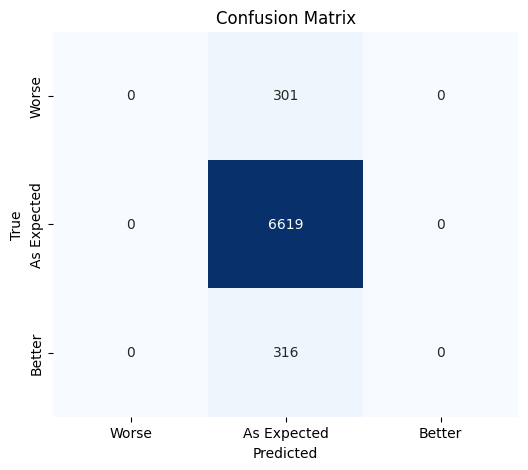

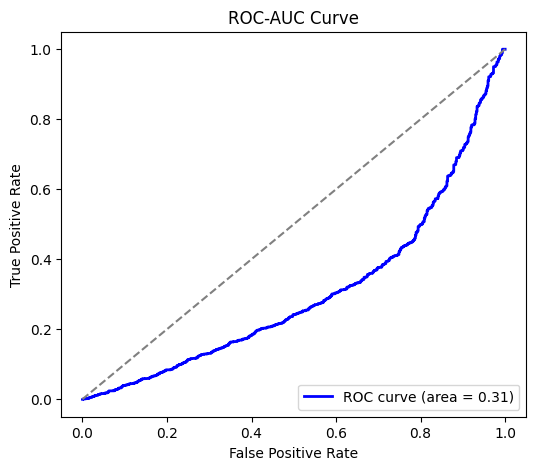

In [32]:

evaluate_model(svm_orig, X_test, y_test, "SVM (Original)")

📊 Random Forest (SMOTE) Evaluation:
Accuracy: 0.9821724709784412
Precision (macro): 0.9239027290302501
ROC AUC (macro): 0.9939484206106078
Confusion Matrix:
[[ 271   30    0]
 [  31 6554   34]
 [   3   31  282]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       301
           1       0.99      0.99      0.99      6619
           2       0.89      0.89      0.89       316

    accuracy                           0.98      7236
   macro avg       0.92      0.93      0.93      7236
weighted avg       0.98      0.98      0.98      7236



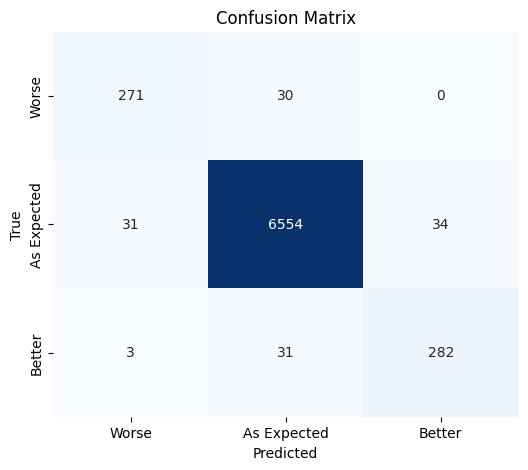

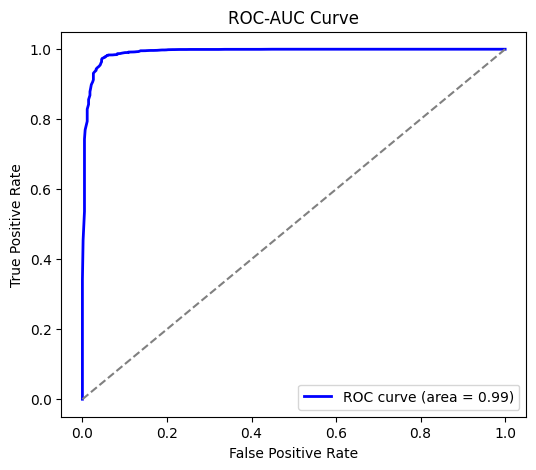

In [34]:
evaluate_model(rf_smote, X_test, y_test, "Random Forest (SMOTE)")

📊 XGBoost (SMOTE) Evaluation:
Accuracy: 0.9603372028745163
Precision (macro): 0.8028241677035348
ROC AUC (macro): 0.9901581753355897
Confusion Matrix:
[[ 276   25    0]
 [  88 6386  145]
 [   3   26  287]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.92      0.83       301
           1       0.99      0.96      0.98      6619
           2       0.66      0.91      0.77       316

    accuracy                           0.96      7236
   macro avg       0.80      0.93      0.86      7236
weighted avg       0.97      0.96      0.96      7236



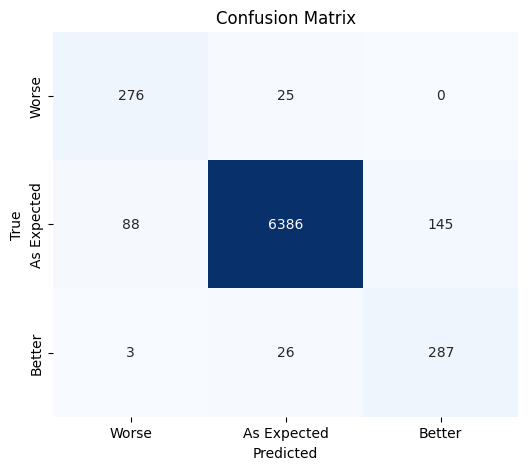

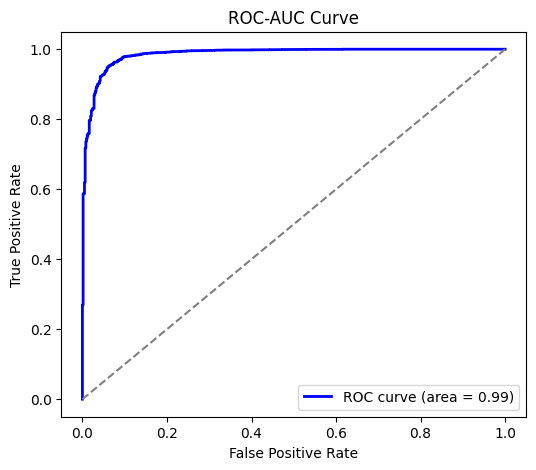

In [35]:
evaluate_model(xgb_smote, X_test, y_test, "XGBoost (SMOTE)")

📊 KNN (SMOTE) Evaluation:
Accuracy: 0.8518518518518519
Precision (macro): 0.5500301259170941
ROC AUC (macro): 0.8855964130788059
Confusion Matrix:
[[ 239   53    9]
 [ 421 5685  513]
 [  13   63  240]]

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.79      0.49       301
           1       0.98      0.86      0.92      6619
           2       0.31      0.76      0.45       316

    accuracy                           0.85      7236
   macro avg       0.55      0.80      0.62      7236
weighted avg       0.92      0.85      0.88      7236



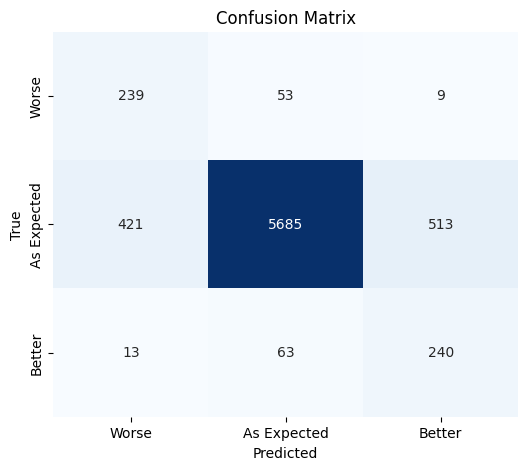

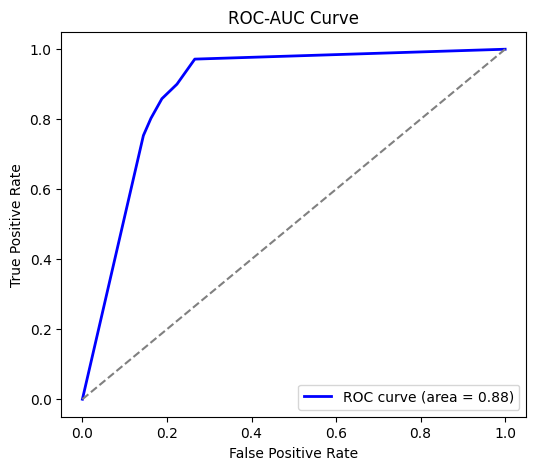

In [36]:
evaluate_model(knn_smote, X_test, y_test, "KNN (SMOTE)")

 SVM (SMOTE) Evaluation:
Accuracy: 0.6380597014925373
Precision (macro): 0.4231572112975706
Recall (macro): 0.6479940197670927
F1 Score (macro): 0.41742834236539633
F1 Score (micro): 0.6380597014925373
ROC AUC (macro): 0.8216758299681387
Log Loss: 0.8335515555846953
Mean Absolute Error (MAE): 0.3732725262576009
Mean Squared Error (MSE): 0.3959369817578773
Root Mean Squared Error (RMSE): 0.629235235629631
Mean Absolute Percentage Error (MAPE): inf
Matthews Correlation Coefficient: 0.24051242252935714
Cohen's Kappa: 0.16501445918370317
R-squared: -3.643670004414939
Confusion Matrix:
[[ 203   52   46]
 [ 829 4214 1576]
 [  36   80  200]]

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.67      0.30       301
           1       0.97      0.64      0.77      6619
           2       0.11      0.63      0.19       316

    accuracy                           0.64      7236
   macro avg       0.42      0.65      0.42      7236
weighte

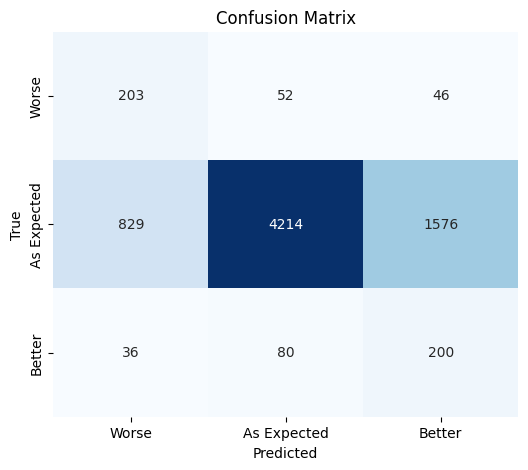

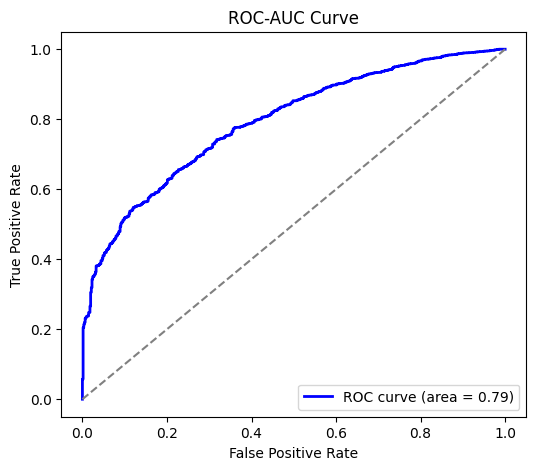

In [61]:
evaluate_model(svm_smote, X_test, y_test, "SVM (SMOTE)")

In [34]:
# Updated evaluation function to return a dictionary of metrics
def get_model_metrics(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    # Calculate metrics
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro'),
        "Recall": recall_score(y_test, y_pred, average='macro'),
        "F1 Score (macro)": f1_score(y_test, y_pred, average='macro'),
        "F1 Score (micro)": f1_score(y_test, y_pred, average='micro'),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE": np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    }

    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_prob, multi_class='ovo', average='macro')
        metrics["Log Loss"] = log_loss(y_test, y_prob)
        metrics["R-squared"] = r2_score(y_test, y_pred)

    # Additional metrics
    # Matthews Correlation Coefficient 
    #metrics["(MCC)"] = matthews_corrcoef(y_test, y_pred)
    #metrics["Cohen's Kappa"] = cohen_kappa_score(y_test, y_pred)
    
    return metrics

# Evaluate all original models
metrics_orig = [
    get_model_metrics(rf_orig, X_test, y_test, "Random Forest (Original)"),
    get_model_metrics(xgb_orig, X_test, y_test, "XGBoost (Original)"),
    get_model_metrics(knn_orig, X_test, y_test, "KNN (Original)"),
    get_model_metrics(svm_orig, X_test, y_test, "SVM (Original)")
]

# Evaluate all SMOTE-trained models
metrics_smote = [
    get_model_metrics(rf_smote, X_test, y_test, "Random Forest (SMOTE)"),
    get_model_metrics(xgb_smote, X_test, y_test, "XGBoost (SMOTE)"),
    get_model_metrics(knn_smote, X_test, y_test, "KNN (SMOTE)"),
    get_model_metrics(svm_smote, X_test, y_test, "SVM (SMOTE)")
]

# Combine into one DataFrame
metrics_all = pd.DataFrame(metrics_orig + metrics_smote)

# Show result table
print(metrics_all)


                      Model  Accuracy  Precision    Recall  F1 Score (macro)  \
0  Random Forest (Original)  0.987322   0.979566  0.869022          0.917880   
1        XGBoost (Original)  0.991091   0.968930  0.932658          0.950220   
2            KNN (Original)  0.939866   0.617511  0.411663          0.450745   
3            SVM (Original)  0.940038   0.313346  0.333333          0.323031   
4     Random Forest (SMOTE)  0.986466   0.921968  0.952807          0.935917   
5           XGBoost (SMOTE)  0.975158   0.838795  0.931741          0.879464   
6               KNN (SMOTE)  0.868083   0.516060  0.830767          0.585802   
7               SVM (SMOTE)  0.617612   0.398739  0.699808          0.375301   

   F1 Score (micro)       MAE       MSE      RMSE  MAPE   ROC-AUC  Log Loss  \
0          0.987322  0.012678  0.012678  0.112595   inf  0.996863  0.048055   
1          0.991091  0.008909  0.008909  0.094386   inf  0.998762  0.027313   
2          0.939866  0.060476  0.061162  0